## Basic Setup

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential, Model
from keras.optimizers import SGD
from keras.applications import MobileNetV2
from keras.regularizers import l2

os.chdir('../../../') # move three level up to the base path
from src.utils import load_and_preprocess_images, plot_history
from src.model_evaluation import evaluate_model
from src.plot_images import plot_images, plot_predictions, plot_false_positives, plot_false_negatives

In [3]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [19]:
model_name = '1_synthetic_eyes'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/Unity_Data_Test_Train'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet'

In [21]:
comment = "hopefully final run"
model_file_path = repo_path + f"/models/mlp/{model_name}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/mlp/{model_name}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/mlp/{model_name}/history/{comment}_history.csv"
# assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [6]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

DATA_AUG_RATE = 0.1
EPOCHS = 100
REGULARIZATION = 0.01
DROPOUT = 0.3
LEARNING_RATE = 0.0001
LOSS_FUNCTION = 'sparse_categorical_crossentropy'
OPTIMIZER = SGD(learning_rate=LEARNING_RATE)

In [7]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=30, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=15, min_lr=0.00001, verbose=1)

In [9]:
synth_train_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
synth_valid_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
synth_test_data = load_and_preprocess_images(syntheticTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 4000 files belonging to 2 classes.
Using 3200 files for training.
Found 4000 files belonging to 2 classes.
Using 800 files for validation.
Found 1000 files belonging to 2 classes.


## Training the Pre-Trained Model

In [10]:
def initialize_mlp_model(title, input_shape, dropout_rate, regularization_rate):
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(128, activation='relu', kernel_regularizer=l2(regularization_rate)),
        Dropout(dropout_rate),
        Dense(2, activation='softmax')
    ], name=title)
    
    # Compile the model
    model.compile(optimizer=OPTIMIZER, loss=LOSS_FUNCTION, metrics=['accuracy'])

    return model

In [11]:
# Build the model
model = initialize_mlp_model(title=model_name, input_shape=INPUT_SHAPE, dropout_rate=DROPOUT, regularization_rate=REGULARIZATION)

/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/.venv/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
# Print model summary to verify
model.summary()

Model: "0_real_eyes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,267,970 (73.50 MB)

 Trainable params: 19,267,970 (73.50 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    synth_train_data,
    validation_data=synth_valid_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
    )

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.5639 - loss: 3.2544
Epoch 1: val_accuracy improved from -inf to 0.77375, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/0_real_eyes/ckpt/hopefully final run_checkpoint.model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 451ms/step - accuracy: 0.5650 - loss: 3.2536 - val_accuracy: 0.7738 - val_loss: 3.1288 - learning_rate: 1.0000e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7403 - loss: 3.1116
Epoch 2: val_accuracy improved from 0.77375 to 0.87375, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/0_real_eyes/ckpt/hopefully final run_checkpoint.model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7407 - loss: 3.1113 - val_accuracy: 0.8737 - val_loss: 3.0415 - learning_rate: 1.0000e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8025 - loss: 3.0433
Epoch 3: val_accuracy improv

In [16]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [22]:
# load the best model
model.load_weights(ckpt_file_path)

In [23]:
# save the model
model.save(model_file_path)

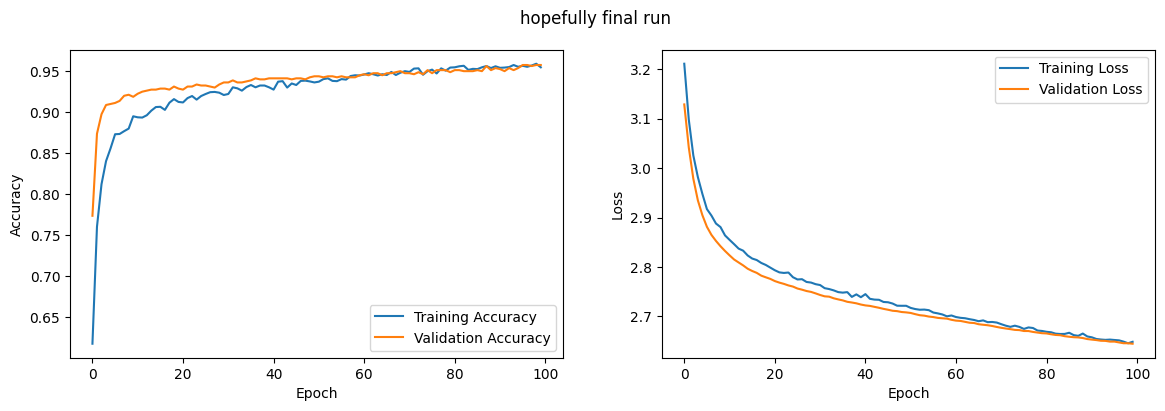

Best train_accuracy: 0.9591
Best train_loss: 2.6458
Best val_accuracy: 0.9575
Best val_loss: 2.6449
Last improvement at epoch: 96


In [24]:
plot_history(comment, history)

Test accuracy: 0.951
Test precision: 0.945
Test recall: 0.958
Test F1 score: 0.951
Prediction time: 1.36 seconds


2024-07-17 00:12:34.345999: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


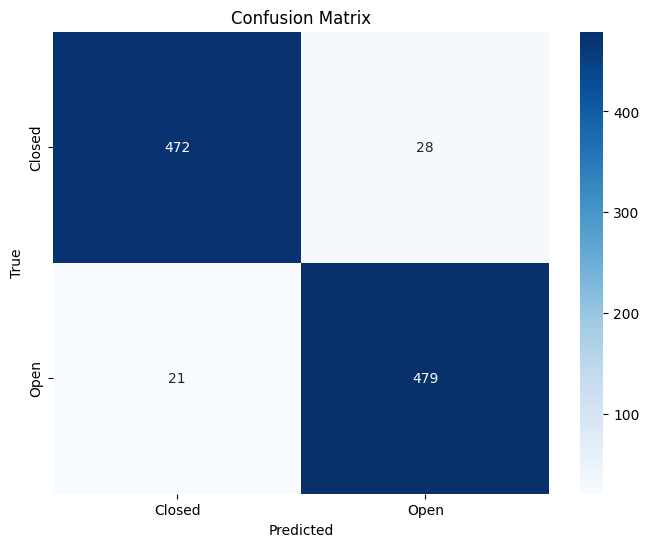

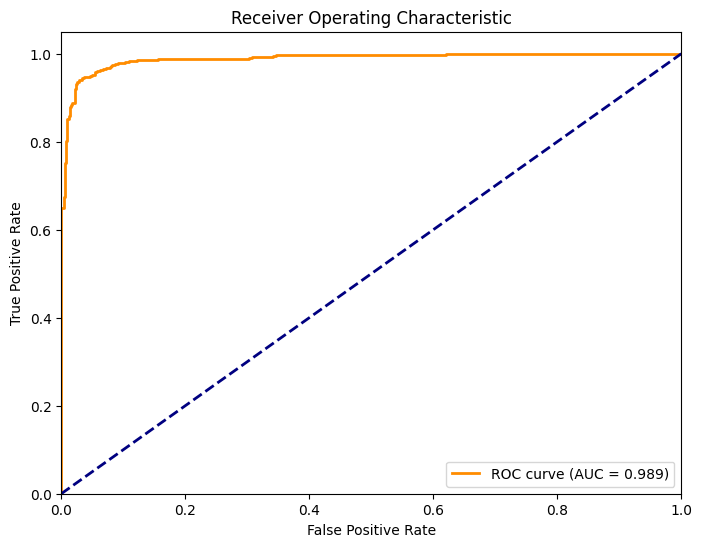

In [25]:
evaluate_model(model, synth_test_data)